In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, RidgeCV, ElasticNet,ElasticNetCV, LassoCV, lasso_path, enet_path
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_validate, KFold

from ISLP.models import (ModelSpec as MS, summarize , poly)


# PCA

In [2]:
from sklearn.decomposition import PCA

## Cluster Data

(-8.0, 8.0)

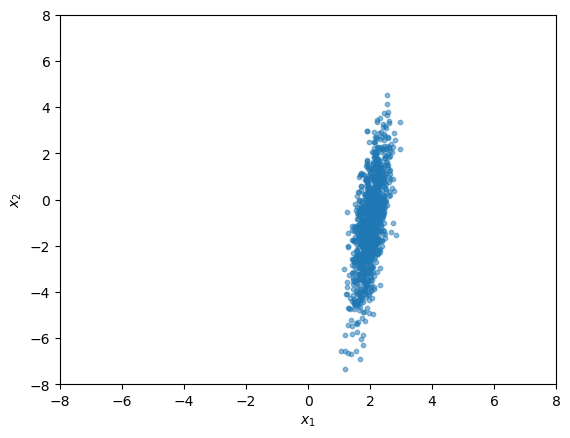

In [3]:
np.random.seed(123)

n = 10**3
weights = np.array([0.4, 0.6])
# x = np.zeros((n, 2))
mean = np.array([2.0, -1.0])
cov = np.array([[0.1, .4], [.4, 4.0]])
x=np.random.multivariate_normal(mean, cov, size=n)
cluster = pd.DataFrame(x, columns=['x1', 'x2'])
fig, axes = plt.subplots()
cluster.plot.scatter("x1", "x2", s=10, alpha=0.5, ax=axes)
axes.set_xlabel(r"$x_1$")
axes.set_ylabel(r"$x_2$")
axes.set_xlim([-8, 8])
axes.set_ylim([-8, 8])


In [4]:
pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster)
cluster_pca

array([[-2.13392755,  0.24737466],
       [ 0.61642195, -0.36606457],
       [-1.11454466,  0.40557701],
       ...,
       [ 3.76189026,  0.20342026],
       [-2.20325088, -0.08317756],
       [-3.18764649,  0.00886394]], shape=(1000, 2))

In [ ]:
cluster_pca[0] # z scores for first observation in the first two principal components

array([-2.13392755,  0.24737466])

In [6]:
pca.components_, pca.explained_variance_ratio_

(array([[ 0.10216889,  0.99476707],
        [ 0.99476707, -0.10216889]]),
 array([0.98613953, 0.01386047]))

In [ ]:
pca.components_[0]

Text(0.5, 1.0, 'PCA Projection of Cluster Data')

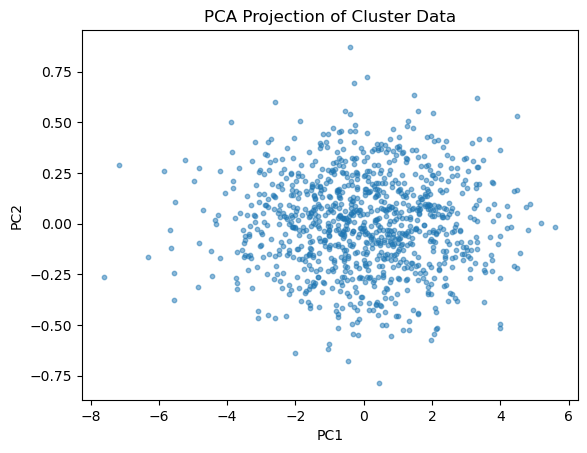

In [7]:
fig, axes = plt.subplots()
axes.scatter(cluster_pca[:, 0], cluster_pca[:, 1], s=10, alpha=0.5)
axes.set_xlabel("PC1")
axes.set_ylabel("PC2")
axes.set_title("PCA Projection of Cluster Data")    

In [ ]:
pca.components_, pca.explained_variance_ratio_

In [ ]:
pca.explained_variance_ratio_.cumsum()

Text(0.5, 1.0, 'Cluster Data with PCA Component Directions')

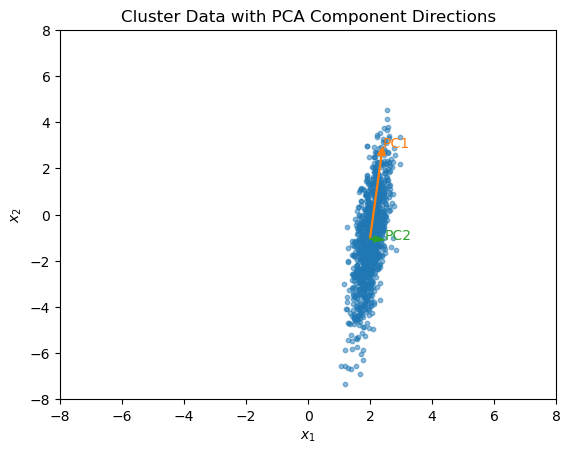

In [9]:
fig, axes = plt.subplots()
cluster.plot.scatter("x1", "x2", s=10, alpha=0.5, ax=axes)

# Draw principal directions from the center of the cloud.
center = pca.mean_
scales = 2 * np.sqrt(pca.explained_variance_)

for i, (direction, scale) in enumerate(zip(pca.components_, scales), start=1):
    vec = direction * scale
    axes.arrow(
        center[0], center[1], vec[0], vec[1],
        color=f"C{i}", width=0.03, length_includes_head=True,
        head_width=0.25, head_length=0.35
    )
    axes.text(center[0] + vec[0], center[1] + vec[1], f"PC{i}", color=f"C{i}")

axes.set_xlabel(r"$x_1$")
axes.set_ylabel(r"$x_2$")
axes.set_xlim([-8, 8])
axes.set_ylim([-8, 8])
axes.set_title("Cluster Data with PCA Component Directions")
# fig.savefig("pca_component_directions.pdf")

In [10]:
pca_pipe = make_pipeline(StandardScaler(), PCA(n_components=2))
cluster_pca_scaled = pca_pipe.fit_transform(cluster)
pca_pipe.named_steps['pca'].components_, pca_pipe.named_steps['pca'].explained_variance_ratio_

(array([[ 0.70710678,  0.70710678],
        [ 0.70710678, -0.70710678]]),
 array([0.82276459, 0.17723541]))

## Iris Data
From https://archive.ics.uci.edu/dataset/53/iris

In [ ]:
iris = pd.read_csv('../data/iris.data', header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])
iris['species'] = iris['species'].astype('category')
iris.head()

In [ ]:
pca_pipe = make_pipeline(StandardScaler(), PCA(n_components=2))
iris_pca_scaled = pca_pipe.fit_transform(iris.drop(columns='species'))

In [ ]:
pca_pipe[1].components_, pca_pipe[1].explained_variance_ratio_

In [ ]:
fig, axes = plt.subplots()
for species, color in zip(iris['species'].cat.categories, ['C0', 'C1', 'C2']):
    species_idx = iris['species'] == species
    axes.scatter(
        iris_pca_scaled[species_idx, 0], iris_pca_scaled[species_idx, 1],
        s=10, alpha=0.5, label=species, color=color
    )

# Add loading vectors for the original features in PC space
loadings = pca_pipe[1].components_.T
feature_names = iris.drop(columns='species').columns
score_scale = np.max(np.abs(iris_pca_scaled[:, :2]), axis=0)
arrow_scale = 0.8

for i, feature in enumerate(feature_names):
    vec = loadings[i, :] * score_scale * arrow_scale
    axes.arrow(
        0, 0, vec[0], vec[1],
        color='black', width=0.015, alpha=0.7,
        head_width=0.12, head_length=0.16, length_includes_head=True
    )
    axes.text(vec[0] * 1.1, vec[1] * 1.1, feature, color='black', fontsize=9)

axes.set_xlabel("PC1")
axes.set_ylabel("PC2")
axes.set_title("PCA Projection of Iris Data with Loading Vectors")  
axes.legend()